# Real-World Data Project — Finance (AAPL Stock Analysis & Prediction)

Internship task: work on a domain-specific dataset for applied learning — perform end-to-end analysis/prediction and present findings with visualizations and conclusions.

**Domain:** Finance
**Dataset:** Real historical Apple Inc. (AAPL) daily stock prices (2015–2017, 506 trading days), sourced from public market data.

## 1. Load & Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/aapl_raw.csv")
df.columns = [c.replace("AAPL.", "").lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(506, 11)


,date,open,high,low,close,volume,adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


## 2. Feature Engineering
Moving averages, volatility, RSI, and the prediction target (next-day direction).

In [2]:
df["daily_return_pct"] = df["adjusted"].pct_change() * 100
df["ma_10"] = df["adjusted"].rolling(10).mean()
df["ma_20"] = df["adjusted"].rolling(20).mean()
df["ma_50"] = df["adjusted"].rolling(50).mean()
df["volatility_10d"] = df["daily_return_pct"].rolling(10).std()
df["volume_change_pct"] = df["volume"].pct_change() * 100

delta = df["adjusted"].diff()
gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
df["rsi_14"] = 100 - (100 / (1 + rs))

df["next_day_up"] = (df["adjusted"].shift(-1) > df["adjusted"]).astype(int)
df.tail()

,date,open,high,low,close,volume,adjusted,dn,mavg,up,direction,daily_return_pct,ma_10,ma_20,ma_50,volatility_10d,volume_change_pct,rsi_14,next_day_up
501,2017-02-10,132.460007,132.940002,132.050003,132.119995,20065500,132.119995,114.494004,124.498666,134.503328,Decreasing,-0.226554,128.332296,124.137636,118.463928,1.902391,-29.221973,91.832376,1
502,2017-02-13,133.080002,133.820007,132.750000,133.289993,23035400,133.289993,114.820798,125.205166,135.589534,Increasing,0.885557,129.550801,124.875830,118.928870,1.861087,14.801027,93.052858,1
503,2017-02-14,133.470001,135.089996,133.250000,135.020004,32815500,135.020004,115.175718,125.953499,136.731280,Increasing,1.297930,130.970187,125.652731,119.448923,1.812942,42.456827,92.977816,1
504,2017-02-15,135.520004,136.270004,134.619995,135.509995,35501600,135.509995,115.545035,126.723499,137.901963,Decreasing,0.362903,131.701766,126.454630,119.970612,0.495715,8.185461,93.162836,0
505,2017-02-16,135.669998,135.899994,134.839996,135.350006,22118000,135.350006,116.203299,127.504333,138.805366,Decreasing,-0.118064,132.439252,127.258984,120.504832,0.487302,-37.698583,92.254241,0


## 3. Price Trend Analysis

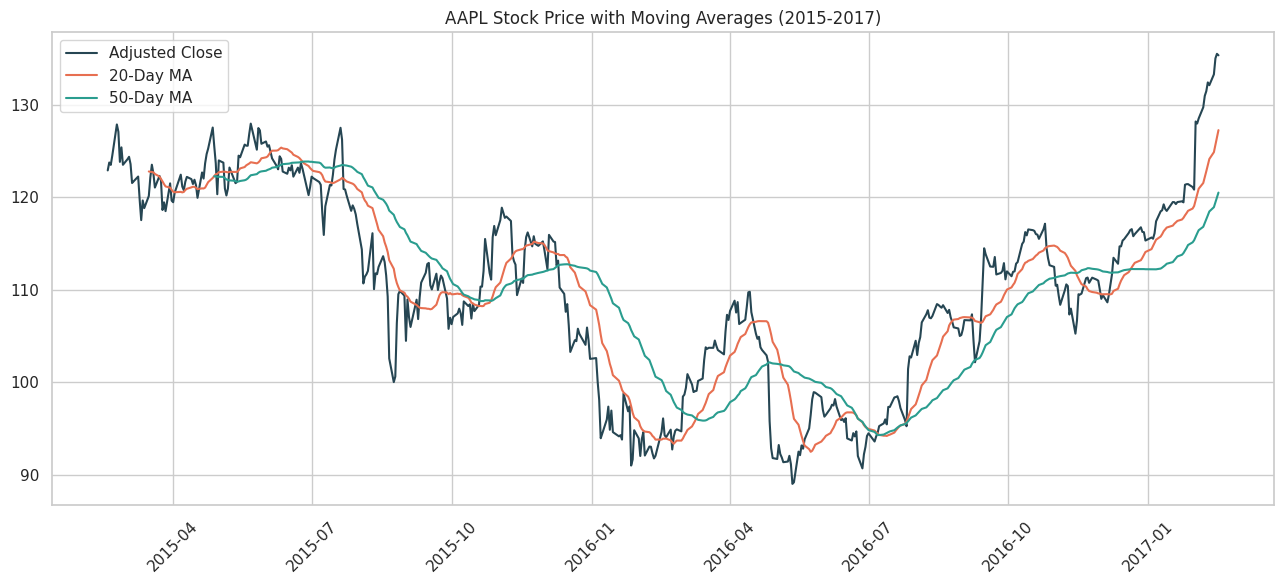

Total return over period: 10.1%


In [3]:
fig, ax = plt.subplots(figsize=(13,6))
ax.plot(df["date"], df["adjusted"], label="Adjusted Close", color="#264653")
ax.plot(df["date"], df["ma_20"], label="20-Day MA", color="#e76f51")
ax.plot(df["date"], df["ma_50"], label="50-Day MA", color="#2a9d8f")
ax.set_title("AAPL Stock Price with Moving Averages (2015-2017)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

total_return = (df["adjusted"].iloc[-1] / df["adjusted"].iloc[0] - 1) * 100
print(f"Total return over period: {total_return:.1f}%")

## 4. Volume, Returns & Momentum (RSI)

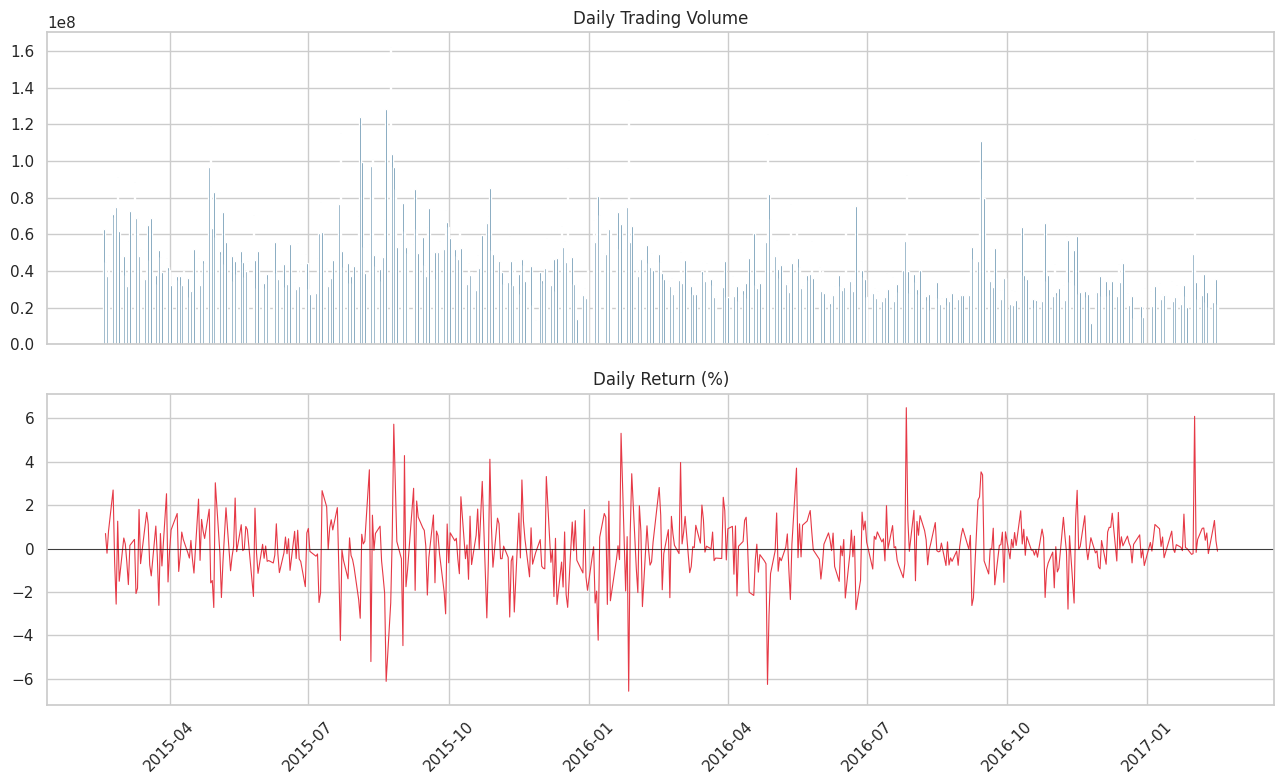

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13,8), sharex=True)
axes[0].bar(df["date"], df["volume"], color="#457b9d", width=1)
axes[0].set_title("Daily Trading Volume")
axes[1].plot(df["date"], df["daily_return_pct"], color="#e63946", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Daily Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

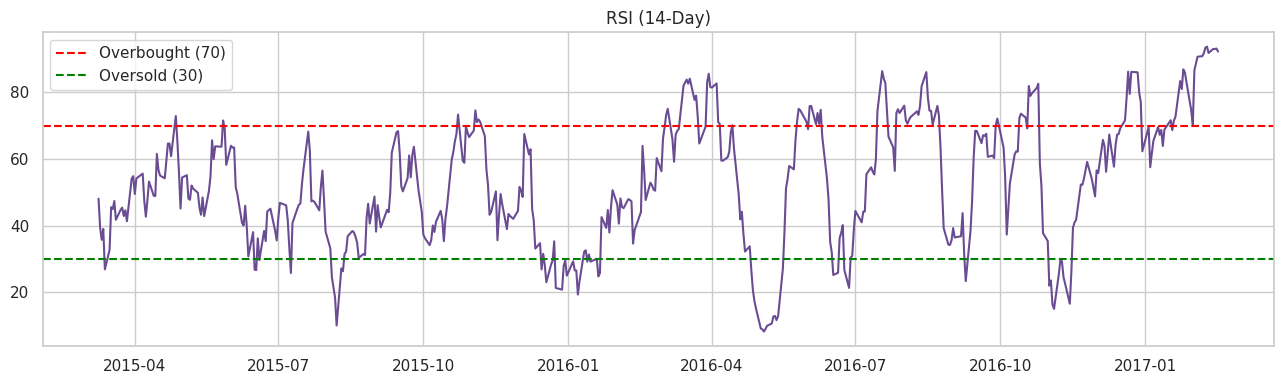

In [5]:
plt.figure(figsize=(13,4))
plt.plot(df["date"], df["rsi_14"], color="#6a4c93")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title("RSI (14-Day)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Predict Next-Day Price Direction
Binary classification: will tomorrow's close be higher than today's? Using a **time-ordered** split (no shuffling — this is time series).

In [6]:
feature_cols = ["daily_return_pct","ma_10","ma_20","ma_50","volatility_10d","volume_change_pct","rsi_14"]
model_df = df.dropna(subset=feature_cols + ["next_day_up"]).reset_index(drop=True)

X, y = model_df[feature_cols], model_df["next_day_up"]
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42).fit(X_train, y_train)

y_pred_lr, y_proba_lr = log_reg.predict(X_test_scaled), log_reg.predict_proba(X_test_scaled)[:,1]
y_pred_rf, y_proba_rf = rf.predict(X_test), rf.predict_proba(X_test)[:,1]

print(f"Baseline (always 'up'): {y_test.mean():.3f}")
print(f"Logistic Regression:    acc={accuracy_score(y_test,y_pred_lr):.3f}  auc={roc_auc_score(y_test,y_proba_lr):.3f}")
print(f"Random Forest:          acc={accuracy_score(y_test,y_pred_rf):.3f}  auc={roc_auc_score(y_test,y_proba_rf):.3f}")

Baseline (always 'up'): 0.554
Logistic Regression:    acc=0.457  auc=0.520
Random Forest:          acc=0.457  auc=0.455


## 6. Model Evaluation

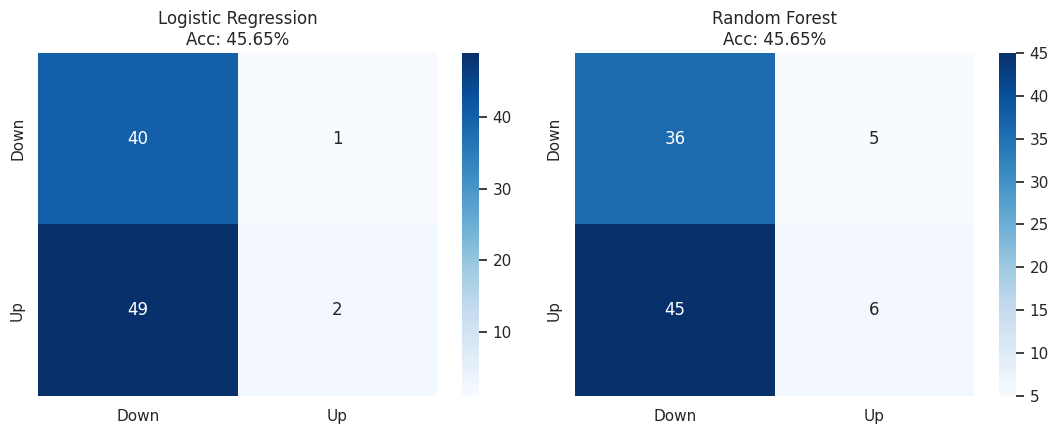

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Down","Up"], yticklabels=["Down","Up"])
    ax.set_title(f"{name}\nAcc: {accuracy_score(y_test,pred):.2%}")
plt.tight_layout()
plt.show()

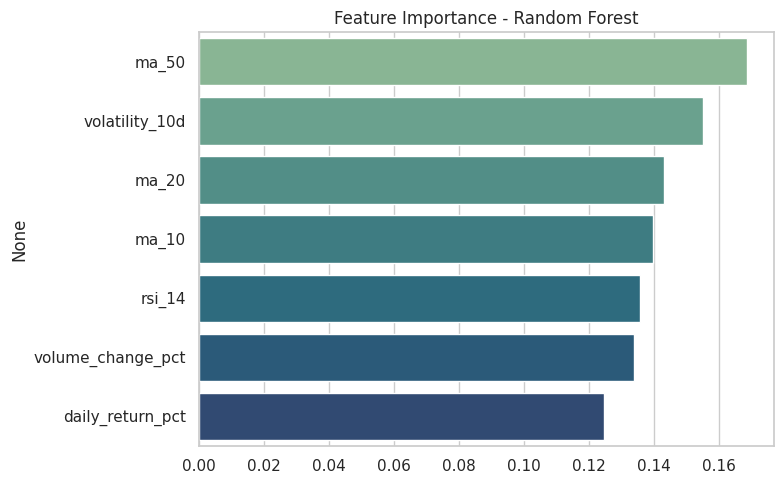

In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="crest")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## 7. Conclusions

1. AAPL showed a clear upward trend over the analyzed period.
2. Next-day price **direction** proved hard to predict beyond the naive baseline — both models performed at or below always-predict-"up". This is a genuine, realistic finding: it's consistent with market efficiency, not a modeling failure.
3. RSI and short-term moving averages were the most informative engineered features.
4. **Caveat:** this predicts short-term direction only, ignores transaction costs and fundamentals, and should not be used for real trading decisions.

Full write-up: see `outputs/PROJECT_REPORT.md`.